In [7]:
import os
from IPython.display import Image, display
import operator
from pydantic.v1.fields import FieldInfo as FieldInfoV1
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import START, END, StateGraph
from langgraph.types import Command, interrupt
os.environ["HTTPS_PROXY"]="" #on some systems proxy is enabled. disabling will allow any network calls.

In [8]:
class State(TypedDict):
    nlist: Annotated[List[str],operator.add] # 

In [9]:
def nodeA(state: State) -> State:
    print("Running Node A")
    note = "Hello from Node A"
    return(State(nlist=[note]))

In [10]:
def nodeB(state: State) -> State:
    print("Running Node B")
    note = "Hello from Node B"
    return(State(nlist=[note]))

In [11]:
def nodeBB(state: State) -> State:
    print("Running Node BB")
    note = "Hello from Node BB"
    return(State(nlist=[note]))

In [12]:
def nodeCC(state: State) -> State:
    print("Running Node CC")
    note = "Hello from Node CC"
    return(State(nlist=[note]))

In [13]:
def nodeD(state: State) -> State:
    print("Running Node D")
    note = "Hello from Node D"
    return(State(nlist=[note]))

In [14]:
def nodeC(state: State) -> State:
    print("Running Node C")
    note = "Hello from Node C"
    return(State(nlist=[note]))

In [16]:
builder = StateGraph(State)
builder.add_node("a",nodeA)
builder.add_node("b",nodeB)
builder.add_node("c",nodeC)
builder.add_node("bb",nodeBB)
builder.add_node("cc",nodeCC)
builder.add_node("d",nodeD)
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "bb")
builder.add_edge("c", "cc")
builder.add_edge("cc", "d")
builder.add_edge("bb", "d")
builder.add_edge("d",END)
graph = builder.compile()


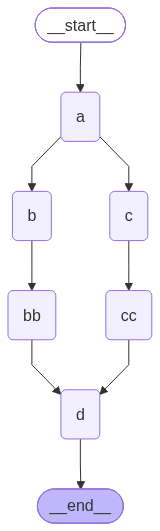

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	a(a)
	b(b)
	c(c)
	bb(bb)
	cc(cc)
	d(d)
	__end__([<p>__end__</p>]):::last
	__start__ --> a;
	a --> b;
	a --> c;
	b --> bb;
	bb --> d;
	c --> cc;
	cc --> d;
	d --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [19]:
display(Image(graph.get_graph().draw_mermaid_png()))
print(graph.get_graph().draw_mermaid())

In [20]:
initialState = State(nlist=["Initial"])
graph.invoke(initialState)

Running Node A
Running Node B
Running Node C
Running Node BB
Running Node CC
Running Node D


{'nlist': ['Initial',
  'Hello from Node A',
  'Hello from Node B',
  'Hello from Node C',
  'Hello from Node BB',
  'Hello from Node C',
  'Hello from Node D']}